<h1>MonReader: Single Frame Modelling (SFM): Model Training 1

In [21]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
TRAIN_DATA_DIR = RAW_DATA_DIR / "training"
TEST_DATA_DIR = RAW_DATA_DIR / "testing"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
SFM_DATA_DIR = PROCESSED_DATA_DIR / "sfm"

MODELS_DIR = PROJ_ROOT / "models"
SFM_MODELS_DIR = MODELS_DIR / "sfm"

In [22]:
import pickle

def load_pickle_data(data_dir):
    """
    Load all pickle files from a directory into a dictionary.

    Parameters
    ----------
    data_dir : str or pathlib.Path
        Directory containing the pickle files. Only files with a `.pkl`
        extension directly within this directory are loaded.

    Returns
    -------
    dict
        Dictionary mapping each pickle file's stem (filename without the
        `.pkl` extension) to its deserialized contents.

    Notes
    -----
    Files are loaded in the order returned by `Path.glob()`. If multiple
    files have the same stem, the last loaded file overwrites earlier
    entries.

    Prints
    ------
    None
        Prints the number of loaded files and their dictionary keys.
    """
    data_dir = Path(data_dir)
    pkl_data = {}

    for pkl_file in data_dir.glob("*.pkl"):
        with pkl_file.open("rb") as file:
            pkl_data[pkl_file.stem] = pickle.load(file)

    print(f"Loaded {len(pkl_data)} pickle files:")
    print(list(pkl_data))

    return pkl_data


pkl_data = load_pickle_data(SFM_DATA_DIR)

Loaded 4 pickle files:
['X_test', 'X_train', 'y_test', 'y_train']


In [23]:
X_train = pkl_data['X_train']
y_train = pkl_data['y_train']
X_test = pkl_data['X_test']
y_test = pkl_data['y_test']

Shuffle the sets as lots of the images will be a sequence of frames of the same clip. We are working with SFM so don't want sequences of similar frames to cause overfitting:

In [24]:
from sklearn.utils import shuffle

def shuffle_training_data(X_train, y_train, random_state=13):
    """
    Randomly shuffle training samples and their corresponding labels.

    The same permutation is applied to both inputs so that each feature
    sample remains paired with its original label.

    Parameters
    ----------
    X_train : array-like
        Training features or images. The first dimension represents samples.
    y_train : array-like
        Training labels corresponding to `X_train`.
    random_state : int or None, default=13
        Seed used to make the shuffle reproducible. Set to ``None`` for
        non-deterministic shuffling.

    Returns
    -------
    X_shuffled : array-like
        Shuffled training features.
    y_shuffled : array-like
        Labels shuffled using the same permutation as `X_shuffled`.

    Raises
    ------
    ValueError
        If `X_train` and `y_train` contain different numbers of samples.

    Example
    -------
    >>> X_train, y_train = shuffle_training_data(X_train, y_train)
    """
    
    if len(X_train) != len(y_train):
        raise ValueError("X_train and y_train must contain the same number of samples.")

    return shuffle(X_train, y_train, random_state=random_state)

X_train, y_train = shuffle_training_data(X_train, y_train)

Generate a validation set from the randomised set + confirm correct image shapes:

In [35]:
from sklearn.model_selection import train_test_split

def create_validation_set(
    X_train,
    y_train,
    val_size=0.2,
    random_state=13,
    stratify=True
):
    """
    Split training data into training and validation subsets.

    The split is reproducible when ``random_state`` is set. When
    ``stratify=True``, both subsets preserve approximately the same
    class distribution as the original training data. The validation
    subset is shuffled after splitting.

    Parameters
    ----------
    X_train : array-like
        Training features or images. The first dimension must represent
        individual samples.
    y_train : array-like
        Class labels corresponding to ``X_train``.
    val_size : float or int, default=0.2
        Proportion or absolute number of samples assigned to the
        validation set.
    random_state : int or None, default=13
        Random seed used to make the split and validation shuffle
        reproducible. Use ``None`` for non-deterministic behavior.
    stratify : bool, default=True
        Whether to preserve the class distribution in both subsets.

    Returns
    -------
    X_train_new : array-like
        Features assigned to the new training set.
    X_val : array-like
        Features assigned to the validation set.
    y_train_new : array-like
        Labels corresponding to ``X_train_new``.
    y_val : array-like
        Labels corresponding to ``X_val``.

    Raises
    ------
    ValueError
        If the input arrays contain different numbers of samples or if
        stratification cannot be performed.

    Examples
    --------
    >>> X_train, X_val, y_train, y_val = create_validation_set(
    ...     X_train, y_train, val_size=0.2, random_state=13
    ... )
    """
    stratify_labels = y_train if stratify else None

    X_train_new, X_val, y_train_new, y_val = train_test_split(
        X_train,
        y_train,
        test_size=val_size,
        stratify=stratify_labels,
        random_state=random_state
    )

    X_val, y_val = shuffle(
        X_val,
        y_val,
        random_state=random_state
    )

    return X_train_new, X_val, y_train_new, y_val


X_train, X_val, y_train, y_val = create_validation_set(
    X_train, y_train, val_size=0.2, random_state=13, stratify=True
)

Using Tensorflow models

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
import matplotlib.pyplot as plt

Next is to build a starter CNN model. The following is a model that I made for a previous computer vision classification project which served well as a starter model.

In [38]:
# Logic added to prevent retraining of saved models when re-executing for saved model evaluation purposes:
train_model_1 = False

In [ ]:
if train_model_1 == True:

    model_1 = Sequential([

    # First Convolutional Block
    Conv2D(32 ,3, padding="same", activation='relu', input_shape=X_train[1].shape), #input shape = (h, w, channel) i.e. image size + channel
    # ReLu allows non-linearity to be considered
    # Convo2D Applies small learnable **filters/kernels** across the image. Each filter learns to detect a particular spatial feature
    BatchNormalization(), #Normalizes the intermediate layer activations per batch (helps to speed training)
    Conv2D(32, 3, activation='relu'), # As above
    MaxPooling2D(), #Reduces spatial dimension by X (H x W -> H/X x w/X). Reduces computation
    Dropout(0.2), # Turn of random proportion of neurons to reduce overfitting.

    # Second Convolutional Block
    Conv2D(128, 3, padding='same',activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.2),

    # Flatten and Dense layers
    GlobalAveragePooling2D(), # Reduces each feature map to a single value by taking its average across the spatial dimensions
    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(2, activation='sigmoid')  # 2 classes for the target
    ])

    # Compile the model
    model_1.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall(),tf.keras.metrics.F1Score(), "accuracy"]
        )
    # Display model summary
    model_1.summary()

    # Implement early stopping to prevent overfitting
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=2
    )

    y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=2)
    y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=2)

    trained_model = model_1.fit(
        X_train,
        y_train_cat,
        batch_size=64, # Batch size can affect training
        epochs=10,
        shuffle=True,
        validation_data=(X_val, y_val_cat),
        callbacks=[early_stopping]
    )

For ~1900 training images:

- Batch size 64 → ~30 gradient updates per epoch
- Batch size 32 → ~60 updates per epoch
- Batch size 16 → ~120 updates per epoch

N.B: BatchNormalization() is being used. Very small batches can make BatchNorm's estimated mean/variance noisier i.e. anything less than 16.


*After training model_1 is updated, so call model_1 for making predictions. trained_model contains the training logs e.g validation and history which should be called when plotting training vs validation curves*

In [29]:
# This was added after training and evaluation (+model + history saving) near the end of the notebook to prevent long retraining when re-executing cells:

def load_model(model_name, model_dir):
    """
    Load a Keras model and its associated training history from disk.

    Parameters
    ----------
    model_name : str
        Base name of the model (without extension).
    model_dir : str or Path
        Directory containing the model (.keras) and history (_history.pkl) files.

    Returns
    -------
    tuple
        (model, history_dict) where model is the loaded Keras model and 
        history_dict is the loaded training history (or None if not found).
    
    Example
    -------
    >>> SFM_MODELS_DIR = "a/directory/containing/models/and/history"
    >>> trained_model,trained_model_history =  load_model("model_1", SFM_MODELS_DIR)
    """

    model_dir = Path(model_dir)
    model_path = model_dir / f"{model_name}.keras"
    history_path = model_dir / f"{model_name}_history.pkl"

    model = tf.keras.models.load_model(model_path)
    print(f"Loaded model from '{model_path}'")

    history_dict = None
    if history_path.exists():
        with open(history_path, "rb") as f:
            history_dict = pickle.load(f)
        print(f"Loaded history from '{history_path}'")
    else:
        print(f"No history file found at '{history_path}'")

    return model, history_dict

In [30]:
if train_model_1 == False:
    trained_model,trained_model_history =  load_model("model_1", SFM_MODELS_DIR)

Loaded model from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_1.keras'
Loaded history from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_1_history.pkl'


Evaluating the initial model:

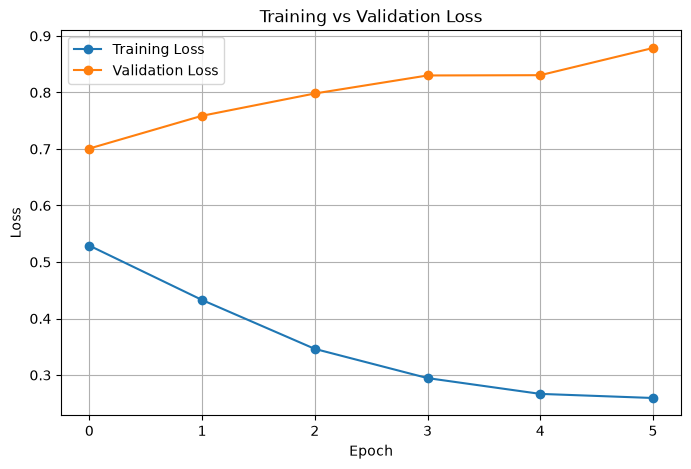

In [ ]:
# Plot training & validation loss curves

def plot_training_history(history, metric='loss'):
    """
    Plots training and validation curves for a given metric from a Keras History dict.

    Parameters
    ----------
    history : dict
        Training history dictionary (e.g. History.history or a loaded history dict).
        Expected to contain keys like 'loss', 'val_loss', 'accuracy', 'val_accuracy', etc.
    metric : str, default='loss'
        The metric to plot. Common options: 'loss', 'accuracy', 'precision', 'recall', 'f1_score'.

    Returns
    -------
    None
        Displays a matplotlib figure with training and validation curves.

    Raises
    ------
    ValueError
        If the specified metric or its validation counterpart is not found in the history dictionary.

    Example
    -------
    >>> plot_training_history(trained_model.history, metric='loss')
    >>> plot_training_history(trained_model_history, metric='accuracy')
    """
    val_metric = f"val_{metric}"

    if metric not in history or val_metric not in history:
        raise ValueError(f"Metric '{metric}' not found in training history.")

    plt.figure(figsize=(8, 5))
    plt.plot(history[metric], marker='o', label=f'Training {metric.capitalize()}')
    plt.plot(history[val_metric], marker='o', label=f'Validation {metric.capitalize()}')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.title(f'Training vs Validation {metric.capitalize()}')
    plt.legend()
    plt.grid(True)
    plt.show()


if train_model_1 == False:
    plot_training_history(trained_model_history, metric='loss')
else:
    trained_model_history = trained_model.history
    plot_training_history(trained_model_history, metric='loss')

This divergence is classic overfitting behaviour. The next steps will be to consider what parts of the model are causing this overfitting and to address them.

Could it be caused by lack of balanced sampling?

Test set evaluation:
  loss: 0.7012868523597717
  compile_metrics: 0.4857621490955353
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 315ms/step

Classification Report:
              precision    recall  f1-score   support

     notflip       0.00      0.00      0.00       307
        flip       0.49      1.00      0.65       290

    accuracy                           0.49       597
   macro avg       0.24      0.50      0.33       597
weighted avg       0.24      0.49      0.32       597

Macro F1-score: 0.3269


c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


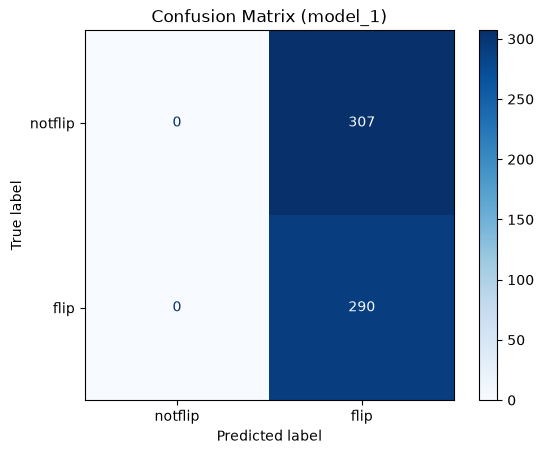

In [39]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay

def evaluate_model(model, X_test, y_test, class_names=("Class 0", "Class 1"), plot_name = ""):
    """
    Evaluate a trained Keras model on test data, printing loss/metrics,
    classification report, F1-score, and displaying a confusion matrix.

    Parameters
    ----------
    model : keras.Model
        Trained Keras model to evaluate.
    X_test : np.ndarray
        Test features.
    y_test : np.ndarray
        Test labels (integer-encoded, not one-hot).
    class_names : tuple of str
        Names for the classes, used in the confusion matrix display.
    plot_name : str
        Name of the model to be displayed in the title of the resulting confusion matrix.

    Returns
    -------
    dict
        Dictionary containing test loss, accuracy, f1_score (macro),
        and the confusion matrix.
    
    Example
    -------
    >>> eval_results = evaluate_model(model_1, X_test, y_test, class_names=('notflip', 'flip'), plot_name="model_1")
    """
    
    # One-hot encode y_test for model.evaluate
    y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=len(class_names))

    # Evaluate using Keras built-in metrics
    results = model.evaluate(X_test, y_test_cat, verbose=0)
    metric_names = model.metrics_names
    print("Test set evaluation:")
    for name, value in zip(metric_names, results):
        print(f"  {name}: {value}")

    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = y_pred_probs.argmax(axis=1)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # F1-score (macro)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    print(f"Macro F1-score: {macro_f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix ({plot_name})")
    plt.show()

    return {
        "test_loss_metrics": dict(zip(metric_names, results)),
        "macro_f1": macro_f1,
        "confusion_matrix": cm
    }

if model_1:
    eval_results = evaluate_model(model_1, X_test, y_test, class_names=('notflip', 'flip'), plot_name="model_1")
else:
    eval_results = evaluate_model(trained_model, X_test, y_test, class_names=('notflip', 'flip'), plot_name="model_1")

Let's save the model for now.

In [ ]:
import os

def save_model(file_path, model, history=None):
    """
    Save a Keras model (and optionally its training history) to disk.

    Parameters
    ----------
    file_path : str
        Destination path for the model file. Saved in the native Keras
        format (`.keras`). Parent directories are created automatically
        if they do not exist.
    model : keras.Model
        Trained Keras model to save.
    history : keras.callbacks.History or dict, optional
        Training history to save alongside the model. If provided, it is
        pickled to a `.pkl` file with the same base name as `file_path`.

    Returns
    -------
    None
        This function writes the model (and optionally history) to disk
        and prints confirmation messages.
    
    Example
    --------
    >>> model_path = "the/path/to/be/saved/to # Don't need to add .pkl or keras at the end.
    >>> save_model(model_path, model_1, model_1.history)
    """
    file_path = str(file_path)
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    # Ensure correct extension for native Keras format
    if not file_path.endswith(".keras"):
        file_path = os.path.splitext(file_path)[0] + ".keras"

    model.save(file_path)
    print(f"Saved model to '{file_path}'")

    # Print size of saved model file in MB
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"Model size: {size_mb:.2f} MB")

    # Print estimated serialized history size
    if history is not None:
        history_dict = history.history if hasattr(history, "history") else history
        history_size_mb = len(pickle.dumps(history_dict)) / (1024 * 1024)
        print(f"History size: {history_size_mb:.4f} MB")

    if history is not None:
        history_dict = history.history if hasattr(history, "history") else history
        history_path = os.path.splitext(file_path)[0] + "_history.pkl"

        with open(history_path, "wb") as f:
            pickle.dump(history_dict, f)

        print(f"Saved history to '{history_path}'")

if train_model_1 == True:
    model_path = SFM_MODELS_DIR / 'model_1' # Don't worry about .pkl or .keras at the end, the function will take care of it.
    save_model(model_path, model_1, model_1.history)